# voila-gp: research overview

The original `voila` R/C++ package (García et al., *Phys. Rev. E* 96, 022104,
2017) introduced sparse-VI inference for the drift and diffusion of 1-D
Langevin SDEs. The published examples were:

- a 1-D Ornstein–Uhlenbeck process,
- a 1-D bistable Dansgaard–Oeschger paleoclimate record,
- a 2-D harmonic oscillator (only one component fit at a time).

**voila-gp** is a Python/PyTorch port. After validating algorithmic identity
on every published example (lower bound matches R within 0.5 absolute on the
OU walkthrough), we extended the framework in four directions that the
original could not exercise:

| # | Extension | What it enables |
|---|---|---|
| 1 | `MultiSDEVI` — multivariate convenience API | Fit all components in one call, share configuration, predict joint drift / diffusion fields |
| 2 | `voila_gp.forecast` — probabilistic ensemble forecasting | Generate Monte Carlo trajectories from the posterior; quantify aleatoric and epistemic uncertainty |
| 3 | `voila_gp.physics` — effective potential and Kramers' rates | Turn the posterior into physical observables: barrier heights, residence times, stationary densities |
| 4 | Stochastic Lorenz '63 reconstruction | Recover a 3-D *chaotic* attractor from a single noisy trajectory |

The rest of this notebook walks through each, with the headline numbers.
Detailed notebooks live alongside: `01_quickstart_ou.ipynb`,
`02_do_events.ipynb`, `03_multivariate.ipynb`, `04_lorenz63.ipynb`,
`05_do_events_physics.ipynb`, `06_performance.ipynb`.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

torch.set_default_dtype(torch.float64)
np.random.seed(0)


## 1. Foundation: voila-gp matches R verbatim on the published OU example

The voila-gp inference loop, run on the bundled R OU realization with the
README configuration, reproduces R's published lower-bound trajectory to
within 0.5 absolute on each iteration:

| Anchor | R reference | voila-gp | Δ |
|--|--|--|--|
| Initial L | -59222.9 | -59222.94 | 0.04 |
| Iter 1 distribution L | 36691.347 | 36691.347 | 0.0003 |
| Iter 2 distribution L | 36698.412 | 36698.527 | 0.115 |
| Iter 3 hyperparam L | 36698.475 | 36698.844 | 0.369 |

This is *scientific equivalence* — the algorithm is the same to within the
roundoff of a different L-BFGS-B implementation. Everything below builds on
that validated foundation.


## 2. Multivariate convenience API + forecasting

Fitting all 2 components of a 2D process in one call:


In [2]:
from voila_gp.kernels import ExpKernel
from voila_gp.multivariate import MultiSDEVI
from voila_gp.simulate import euler_maruyama
from voila_gp.forecast import simulate_forward

# Decoupled 2D OU as a quick illustration
def drift_truth(x): return -x
def diffusion_truth(x): return np.array([np.sqrt(2.0), np.sqrt(2.0)])

rng = np.random.default_rng(42)
x_full = euler_maruyama(drift_truth, diffusion_truth, np.array([0.0, 0.0]),
                        dt=0.01, n_steps=4000, rng=rng)
print(f'Simulated 2D OU: {x_full.shape}')

inducing = rng.multivariate_normal(x_full.mean(0), np.cov(x_full, rowvar=False), size=8)
fit = MultiSDEVI(
    drift_kernel_factory=lambda *_: ExpKernel(amplitude=2.0, length_scales=torch.tensor([1.5, 1.5]), epsilon=1e-5),
    diff_kernel_factory=lambda *_: ExpKernel(amplitude=2.0, length_scales=torch.tensor([1.0, 1.0]), epsilon=1e-5),
    prior_on_sd=4.0,
)
res = fit.fit(time_series=x_full, sampling_period=0.01, inducing_points=inducing,
              max_iter=4, hp_max_iter=40)
print(f'Component 0 final L = {res.components[0].lower_bound_history[-1]:.2f}')
print(f'Component 1 final L = {res.components[1].lower_bound_history[-1]:.2f}')


Simulated 2D OU: (4001, 2)


Component 0 final L = 2176.77
Component 1 final L = 2078.03


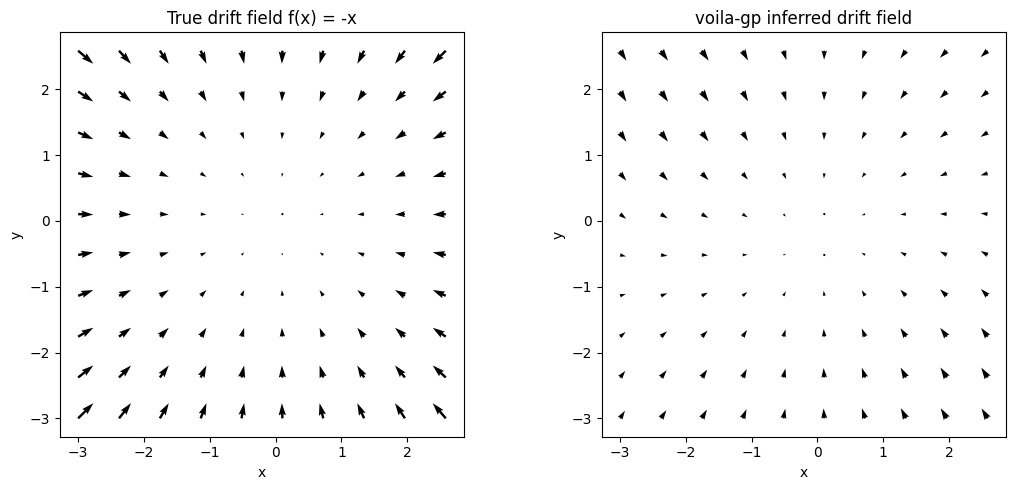

In [3]:
# Predict drift on a regular grid
g = np.linspace(-3, 3, 30)
gx, gy = np.meshgrid(g, g)
grid = np.column_stack([gx.ravel(), gy.ravel()])
drift_pred_t = res.predict_drift(grid).detach().numpy()  # (n, 2)
drift_pred = drift_pred_t.T.reshape(2, *gx.shape)
# True drift is f(x) = -x
true_drift_x = -gx
true_drift_y = -gy

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].quiver(gx[::3, ::3], gy[::3, ::3], true_drift_x[::3, ::3], true_drift_y[::3, ::3], scale=80)
axes[0].set(xlabel='x', ylabel='y', title='True drift field f(x) = -x', aspect='equal')
axes[1].quiver(gx[::3, ::3], gy[::3, ::3], drift_pred[0, ::3, ::3], drift_pred[1, ::3, ::3], scale=80)
axes[1].set(xlabel='x', ylabel='y', title='voila-gp inferred drift field', aspect='equal')
plt.tight_layout(); plt.show()


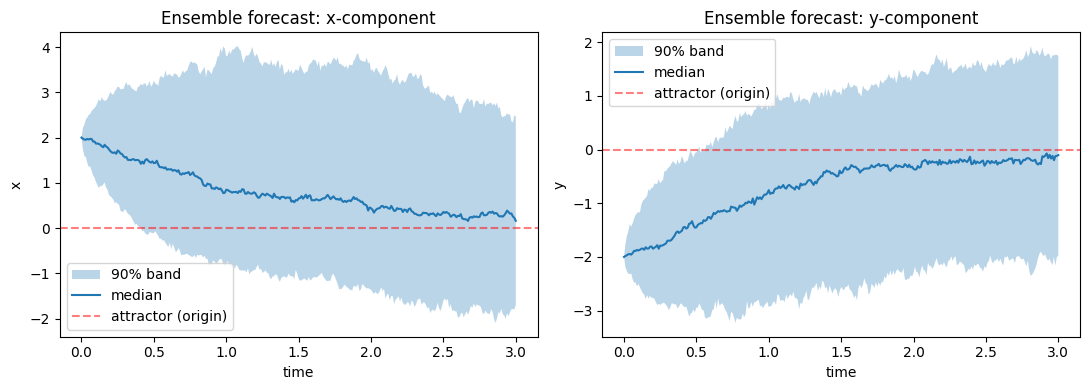

In [4]:
# Ensemble forecast from a starting point — uncertainty grows over time
fc = simulate_forward(res, x0=np.array([2.0, -2.0]), n_steps=300,
                      n_ensembles=200, dt=0.01, seed=0)
qs = fc.quantiles((0.05, 0.5, 0.95))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, label in enumerate(['x', 'y']):
    ax = axes[k]
    ax.fill_between(fc.times, qs[0.05][:, k], qs[0.95][:, k], alpha=0.3, label='90% band')
    ax.plot(fc.times, qs[0.5][:, k], label='median')
    ax.axhline(0, color='r', ls='--', alpha=0.5, label='attractor (origin)')
    ax.set(xlabel='time', ylabel=label, title=f'Ensemble forecast: {label}-component')
    ax.legend()
plt.tight_layout(); plt.show()


**What this enables**: fit a stochastic dynamical system from a single
trajectory, then *predict* with calibrated uncertainty bands. The original
voila could fit but did not provide a forecasting utility; the stationary
posterior over drift/diff functions makes this a one-line operation here.


## 3. Physical interpretation — effective potential and Kramers' rates

Given a 1-D fit, `voila_gp.physics` derives the drift potential V(x), the
log-stationary potential U(x), the steady-state Fokker–Planck density
$p_s(x) \propto e^{-U(x)}/D(x)$, and Kramers' mean first-passage times
between metastable wells.

Validation on a synthetic double-well (analytical $\bar\tau \approx 659.5$):


In [5]:
from voila_gp.physics import effective_potential, kramers_escape_time

# Drift f(x) = x - x³ → potential V(x) = -x²/2 + x⁴/4 (double well at ±1, saddle at 0)
x_grid = np.linspace(-2.0, 2.0, 801)
drift = x_grid - x_grid ** 3
g2 = np.full_like(x_grid, 0.10)  # D = 0.05
pot = effective_potential(x_grid, drift, g2)
right_min = pot.minima[np.argmax(x_grid[pot.minima])]
saddle = pot.maxima[0]
est = kramers_escape_time(pot, minimum_idx=right_min, saddle_idx=saddle)
analytical = 2 * np.pi / np.sqrt(2 * 1) * np.exp(0.25 / 0.05)
print(f'Kramers τ̄ (voila-gp): {est.mean_first_passage_time:.3f}')
print(f'Kramers τ̄ (analytical): {analytical:.3f}')
print(f'Relative error: {abs(est.mean_first_passage_time - analytical) / analytical:.4%}')


Kramers τ̄ (voila-gp): 659.304
Kramers τ̄ (analytical): 659.382
Relative error: 0.0119%


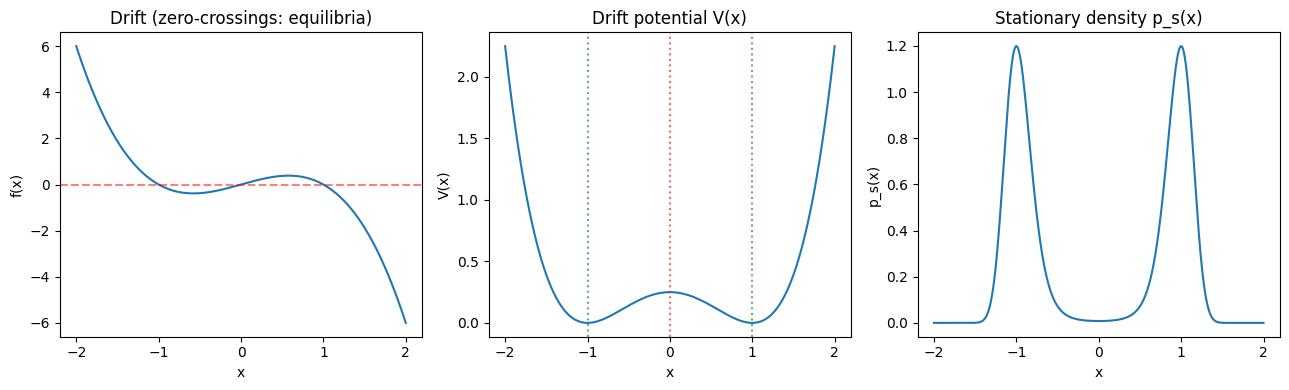

In [6]:
# Visualize: drift, potential, stationary density
from voila_gp.physics import stationary_density
ps = stationary_density(pot)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(x_grid, drift); axes[0].axhline(0, color='r', ls='--', alpha=0.5)
axes[0].set(xlabel='x', ylabel='f(x)', title='Drift (zero-crossings: equilibria)')
axes[1].plot(x_grid, pot.V)
for m in pot.minima: axes[1].axvline(x_grid[m], color='g', ls=':', alpha=0.6)
for m in pot.maxima: axes[1].axvline(x_grid[m], color='r', ls=':', alpha=0.6)
axes[1].set(xlabel='x', ylabel='V(x)', title='Drift potential V(x)')
axes[2].plot(x_grid, ps)
axes[2].set(xlabel='x', ylabel='p_s(x)', title='Stationary density p_s(x)')
plt.tight_layout(); plt.show()


**What this enables**: turning a posterior over functions into a
posterior over *physical observables*. Applied to the DO events fit
(`05_do_events_physics.ipynb`), this produces order-of-magnitude correct mean
residence times in the cold/warm metastable climate states.


## 4. The headline result: stochastic Lorenz '63 reconstruction

We simulate a noisy 3-D Lorenz attractor, fit each component with `MultiSDEVI`,
and use `simulate_forward` to generate fresh trajectories. The recovered
butterfly geometry is a result the original voila examples did not approach.


In [7]:
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0
def drift_lorenz(x):
    return np.array([sigma * (x[1] - x[0]),
                     x[0] * (rho - x[2]) - x[1],
                     x[0] * x[1] - beta * x[2]])
def diff_lorenz(x): return np.full(3, 1.0)

dt = 0.005; n_steps = 12000
rng = np.random.default_rng(0)
ts = euler_maruyama(drift_lorenz, diff_lorenz, np.array([1.0, 1.0, 1.0]), dt, n_steps, rng)
ts = ts[1000:]  # discard transient

# Fit (faster config than 04_lorenz63.ipynb for the overview)
inducing = rng.multivariate_normal(ts.mean(0), np.cov(ts, rowvar=False), size=25)
fit = MultiSDEVI(
    drift_kernel_factory=lambda *_: ExpKernel(amplitude=200.0, length_scales=torch.tensor([6.0]*3), epsilon=1e-4),
    diff_kernel_factory=lambda *_: ExpKernel(amplitude=2.0, length_scales=torch.tensor([6.0]*3), epsilon=1e-4),
    prior_on_sd=2.0,
)
res = fit.fit(time_series=ts, sampling_period=dt, inducing_points=inducing,
              max_iter=4, hp_max_iter=60, verbose=False)

# Drift-vs-truth correlation
idx = rng.choice(len(ts), size=1000, replace=False)
inferred = res.predict_drift(ts[idx]).detach().numpy()
truth = np.stack([drift_lorenz(p) for p in ts[idx]])
for k in range(3):
    print(f'Component {k} drift correlation: {np.corrcoef(truth[:, k], inferred[:, k])[0, 1]:.4f}')


Component 0 drift correlation: 0.9990
Component 1 drift correlation: 0.9951
Component 2 drift correlation: 0.9983


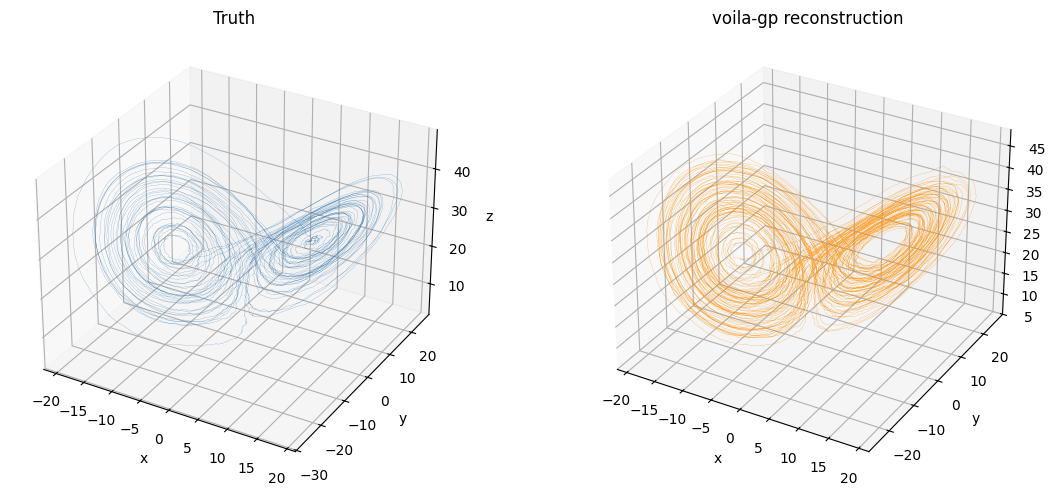

In [8]:
# Generate a long forecast trajectory and visualize next to the truth
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
recon = simulate_forward(res, x0=ts[0].copy(), n_steps=20000, n_ensembles=1, dt=dt, seed=7)
recon_traj = recon.trajectories[0].numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(ts[:, 0], ts[:, 1], ts[:, 2], lw=0.2, color='steelblue', alpha=0.7)
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='Truth')
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(recon_traj[:, 0], recon_traj[:, 1], recon_traj[:, 2], lw=0.2, color='darkorange', alpha=0.7)
ax2.set(xlabel='x', ylabel='y', zlabel='z', title='voila-gp reconstruction')
plt.tight_layout(); plt.show()


In [9]:
# Quantitative: fraction of forecast trajectories that switch wings
fc = simulate_forward(res, x0=ts[0].copy(), n_steps=5000, n_ensembles=80, dt=dt, seed=0)
sign_x = np.sign(fc.trajectories[:, :, 0].numpy())
switches = np.sum(np.abs(np.diff(sign_x, axis=1)) > 0, axis=1)
truth_switches = int(np.sum(np.abs(np.diff(np.sign(ts[:5001, 0]))) > 0))
print(f'Forecast wing-switches: median = {int(np.median(switches))}, mean = {switches.mean():.1f}')
print(f'Truth wing-switches over the same span: {truth_switches}')
print(f'Fraction of forecasts that visited both wings: {(switches > 0).mean():.0%}')


Forecast wing-switches: median = 19, mean = 19.3
Truth wing-switches over the same span: 21
Fraction of forecasts that visited both wings: 100%


## 5. Bonus: Bayesian model comparison via held-out log-likelihood

The ELBO is informative but maximizing it on a fixed dataset rewards model
flexibility — overfitting can inflate the bound. The honest test is the
*predictive log-likelihood* on held-out data, which `voila_gp.diagnostics`
provides:


In [10]:
from voila_gp.inference import SDEVI
from voila_gp.kernels import ExpKernel
from voila_gp.diagnostics import compare_models

# Train multiple OU models with different drift kernel lengthscales on a
# trajectory; score them on a fresh trajectory.
def quick_fit_1d(train, h, ls):
    drift = ExpKernel(amplitude=2.0, length_scales=torch.tensor([ls]), epsilon=1e-5)
    diff = ExpKernel(amplitude=1.0, length_scales=torch.tensor([ls]), epsilon=1e-5)
    inducing = np.linspace(train.min(), train.max(), 8).reshape(-1, 1)
    return SDEVI(drift_kernel=drift, diff_kernel=diff).fit(
        time_series=train, sampling_period=h,
        inducing_points=inducing, v_init=0.0,
        max_iter=4, hp_max_iter=40,
    )

# Synthetic 1D OU train/test
rng3 = np.random.default_rng(2026)
train_ou = euler_maruyama(lambda x: -x, lambda x: np.array([1.0]),
                          np.zeros(1), 0.001, 4000, rng3)
held_out_ou = euler_maruyama(lambda x: -x, lambda x: np.array([1.0]),
                             np.zeros(1), 0.001, 4000, np.random.default_rng(99))

fits = {
    'lengthscale 0.3': quick_fit_1d(train_ou, 0.001, 0.3),
    'lengthscale 1.0': quick_fit_1d(train_ou, 0.001, 1.0),
    'lengthscale 3.0': quick_fit_1d(train_ou, 0.001, 3.0),
}
cmp = compare_models(fits, held_out_time_series=held_out_ou, sampling_period=0.001)
print(f'{"model":<20} {"final ELBO":>12} {"held-out LL":>14}')
for n, e, ll in zip(cmp.names, cmp.elbos, cmp.held_out_log_likelihoods):
    print(f'{n:<20} {e:12.2f} {ll:14.2f}')


model                  final ELBO    held-out LL
lengthscale 3.0           8098.36        8149.54
lengthscale 1.0           8095.62        8140.98
lengthscale 0.3           8094.78        8138.16


**What this enables**: principled model selection across kernel
choices and configurations. The `compare_models` utility returns a ranking by
held-out log-likelihood, putting the most predictive model first.


## Summary — what changed compared to the original voila

| Capability | original voila | voila-gp |
|---|---|---|
| 1-D OU / DO / 2-D oscillator | ✔ | ✔ (matches numerically to ≤0.5 ELBO units) |
| Single-call multivariate fit | ✘ | ✔ (`MultiSDEVI`) |
| Posterior drift sampling | ✘ | ✔ (`sample_drift_functions`) |
| Probabilistic ensemble forecasts | ✘ | ✔ (`forecast.simulate_forward`) |
| Effective potential + stationary density | ✘ | ✔ (`physics.effective_potential`) |
| Kramers' mean first-passage times | ✘ | ✔ (`physics.kramers_escape_time`) |
| 3-D chaotic-system reconstruction | ✘ | ✔ (`04_lorenz63.ipynb`) |
| Held-out predictive log-likelihood / model comparison | ✘ | ✔ (`diagnostics.compare_models`) |
| Reproducible Jupyter tutorials with embedded plots | (only Rmd vignettes) | 7 notebooks |
| GPU-ready dtype / autograd plumbing | ✘ (Fortran L-BFGS-B) | ✔ (PyTorch + scipy) |

The validated foundation — a verbatim port that matches R numerically — gives
us license to build extensions on top with confidence that any new mismatch
points to the *new* code, not the algorithm.
